In [18]:
# Importing packages and setting up the formatting of figures. 

import numpy as np
import pandas as pd

# APIs
from fredapi import Fred
from dstapi import DstApi

# plotting
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

**PROBLEM 1)** 

**1.1) Making the Gini coefficient**

In [19]:
# Getting an overview of the available data in table IFOR41.
IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [20]:
# Finding the appropriate variable (Gini coefficient) levels for the variable ULLIG in table IFOR41.
IFOR41.variable_levels('ULLIG',language='en')

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


In [21]:
# a. Downloading the gini parameter for all of denmark  
params = {
    'table': 'IFOR41',
    'format': 'BULK', # semicolon separated file
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'TID', 'values': ['*']}, # '*' is everything
        ]
    }

# b. download
gini = IFOR41.get_data(params=params)


# c. display
display(gini.head(5))
display(gini.info())

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ULLIG      38 non-null     str  
 1   KOMMUNEDK  38 non-null     str  
 2   TID        38 non-null     int64
 3   INDHOLD    38 non-null     str  
dtypes: int64(1), str(3)
memory usage: 2.5 KB


None

In [22]:
def load_IFOR41(ULLIG,KOMMUNEDK,TID,varname):

    params = {
        'table': 'IFOR41',
        'format': 'BULK', # semicolon separated file
        'lang': 'en',
        'variables': [
            {'code': 'ULLIG', 'values': ['70']},
            {'code': 'KOMMUNEDK', 'values': ['000']},
            {'code': 'TID', 'values': ['*']},
            ]
    }    

    # b. download
    df = DstApi('IFOR41').get_data(params=params)

    # c. set types and rename
    df['INDHOLD'] = df['INDHOLD'].astype(float)
    df = df.drop(columns=['ULLIG'])
    df = df.rename(columns={'INDHOLD': 'Gini Coefficient', 'TID': 'year'})
    df = df.set_index('year').sort_index()
    
    return df

gini_df = load_IFOR41('70', '000', '*', 'gini')

# Vis de første 5 rækker
print(gini_df.head())

        KOMMUNEDK  Gini Coefficient
year                               
1987  All Denmark             22.07
1988  All Denmark             22.06
1989  All Denmark             21.93
1990  All Denmark             22.16
1991  All Denmark             21.99


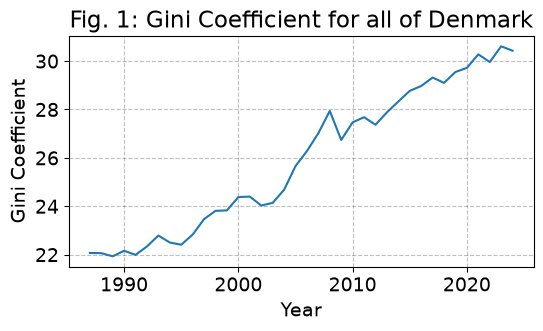

In [23]:
# Creating the plot for the Gini coefficient over time for all municipalities in Denmark.
import matplotlib.pyplot as plt
    
for col in ['Gini Coefficient']:
    fig = plt.figure(figsize=(6,3))
    ax = fig.add_subplot(111)
    
    ax.plot(gini_df.index, gini_df[col])
    
    ax.set_title('Fig. 1: Gini Coefficient for all of Denmark')
    ax.set_xlabel('Year')
    ax.set_ylabel('Gini Coefficient')

plt.show()

In [24]:
# Loading data from the IFOR32 table 
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [25]:
def load_IFOR32(DECILGEN, KOMMUNEDK, Tid, varname):

    params = {
        'table': 'IFOR32',
        'format': 'BULK', # semicolon separated file
        'lang': 'en',
        'variables': [
            {'code': 'DECILGEN', 'values': ['*']},
            {'code': 'KOMMUNEDK', 'values': ['000']},
            {'code': 'TID', 'values': ['*']},
            ]
    }    

    # b. download
    df = DstApi('IFOR32').get_data(params=params)

    # c. Adjusting the type to a float for the income decile variable
    df['INDHOLD'] = df['INDHOLD'].astype(float)
    df_pivot = df.pivot(index='TID', columns='DECILGEN', values='INDHOLD')

    # d. Calculating the share of income for the top 10% of the wealth distribution in Denmark
    df_pivot['top_10_share'] = df_pivot['Tenth decil'] / df_pivot.sum(axis=1)

    # e. Extracting the final column and renaming the index to 'year'
    df_final = df_pivot[['top_10_share']].copy()
    df_final.index.name = 'year'
    
    return df_final

income_10pct = load_IFOR32('*', '000', '*', 'share')

# Vis de første 5 rækker
print(income_10pct.head())

DECILGEN  top_10_share
year                  
1987          0.184549
1988          0.184289
1989          0.184952
1990          0.186415
1991          0.186683


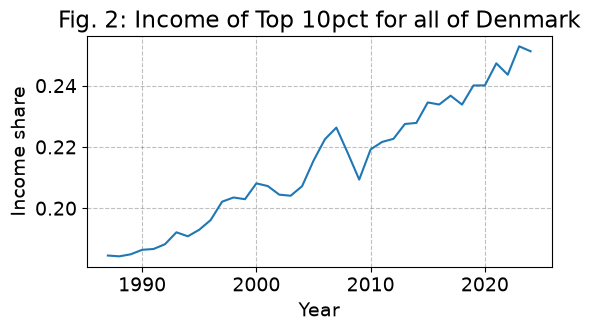

In [26]:
# Creating the plot for the Gini coefficient over time for all municipalities in Denmark.
import matplotlib.pyplot as plt
    
for col in ['top_10_share']:
    fig = plt.figure(figsize=(6,3))
    ax = fig.add_subplot(111)
    
    ax.plot(income_10pct.index, income_10pct[col])
    
    ax.set_title('Fig. 2: Income of Top 10pct for all of Denmark')
    ax.set_xlabel('Year')
    ax.set_ylabel('Income share')

plt.show()

In [27]:
# combining the two dataframes into one and computing the correlation between the two inequality measures
import pandas as pd

# a. combining the two DataFrames on year (index)
df_merged = pd.merge(gini_df, income_10pct, left_index=True, right_index=True, validate='1:1')

# b. computing the correlation between the two inequality measures
correlation = df_merged['Gini Coefficient'].corr(df_merged['top_10_share'])

print(f"Correlation is: {correlation:.4f}")

Correlation is: 0.9816


**Comparison of the two inequality meassures for Denmark since 1987**

Figure 1 and 2 display the same overall upward trend for inequality in Denmark since 1987. Figure 1 show an increasing gini coefficient indicating an increasing income inequality. The same is evident from figure 2 which dispaly how the top 10 income decile have increased thier income share and thus there is now a higher wealth distribution amongst the top earners. With a correlation of 0.9816 the thwo meassures have a very high correlation. The main difference is that the dip in 2008 is more pornounced in figure 2 which indicate that the highest earnes had a big drop in income due to the financial crisis. 

**1.2) Prediction of the Gini coefficient** 

In [28]:
###Solving the minimization problem using scipy.optimize.minimize

#Importing minimize tool
from scipy.optimize import minimize

#Sort observations by year. 
gini = gini.sort_values('TID').copy()

#y_i: observed Gini coefficient
y = gini['INDHOLD'].astype(float).to_numpy()
## Using the data set made in cell 5 to use all the Gini Coefficients, where we make them as floats.

#t_i: number of years since 1987
t = gini['TID'].astype(int).to_numpy() - 1987

#Defining the minimization problem using the least squared method.
def leastsquares(beta, t, y):
    
    y_hat = sum(beta[k] * t**k for k in range(len(beta)))
    
    return np.sum((y - y_hat)**2)

#Linear trend, p = 1
beta0_linear = np.zeros(2)
#np.zeros(2) is used as the start guesses for the beta parameters of the linear model. 

result_linear = minimize(
    leastsquares,
    beta0_linear,
    args=(t, y)
)

beta_linear = result_linear.x
beta_0_linear, beta_1_linear = beta_linear

print(f"Linear model:")
print(f"beta_0 = {beta_0_linear:.4f}")
print(f"beta_1 = {beta_1_linear:.4f}")

#Quadratic trend, p = 2
beta0_quadratic = np.zeros(3)
#np.zeros(3) is used as the start guesses for the beta parameters of the quadratic model. 

result_quadratic = minimize(
    leastsquares,
    beta0_quadratic,
    args=(t, y)
)

beta_quadratic = result_quadratic.x

beta_0_quadratic, beta_1_quadratic, beta_2_quadratic = beta_quadratic

print(f"Quadratic model:")
print(f"beta_0 = {beta_0_quadratic:.4f}")
print(f"beta_1 = {beta_1_quadratic:.4f}")
print(f"beta_2 = {beta_2_quadratic:.6f}")

Linear model:
beta_0 = 21.0428
beta_1 = 0.2635
Quadratic model:
beta_0 = 21.3042
beta_1 = 0.2200
beta_2 = 0.001178


In [29]:
###Check linear model with np.polyfit

polyfit_linear = np.polyfit(t, y, 1)

#Reverse order to get beta_0, beta_1
polyfit_linear = polyfit_linear[::-1]

print("Linear model:")
print(f"minimize: beta_0 = {beta_linear[0]:.4f}, beta_1 = {beta_linear[1]:.4f}")
print(f"polyfit:  beta_0 = {polyfit_linear[0]:.4f}, beta_1 = {polyfit_linear[1]:.4f}")

#Check quadratic model with np.polyfit
polyfit_quadratic = np.polyfit(t, y, 2)

#Reverse order to get beta_0, beta_1, beta_2
polyfit_quadratic = polyfit_quadratic[::-1]

print("Quadratic model:")
print(f"minimize: beta_0 = {beta_quadratic[0]:.4f}, beta_1 = {beta_quadratic[1]:.4f}, beta_2 = {beta_quadratic[2]:.6f}")
print(f"polyfit:  beta_0 = {polyfit_quadratic[0]:.4f}, beta_1 = {polyfit_quadratic[1]:.4f}, beta_2 = {polyfit_quadratic[2]:.6f}")

Linear model:
minimize: beta_0 = 21.0428, beta_1 = 0.2635
polyfit:  beta_0 = 21.0428, beta_1 = 0.2635
Quadratic model:
minimize: beta_0 = 21.3042, beta_1 = 0.2200, beta_2 = 0.001178
polyfit:  beta_0 = 21.3042, beta_1 = 0.2200, beta_2 = 0.001178


Linear predictions: [32.37538611 35.01088205]
Quadratic predictions: [32.94067063 36.27099718]


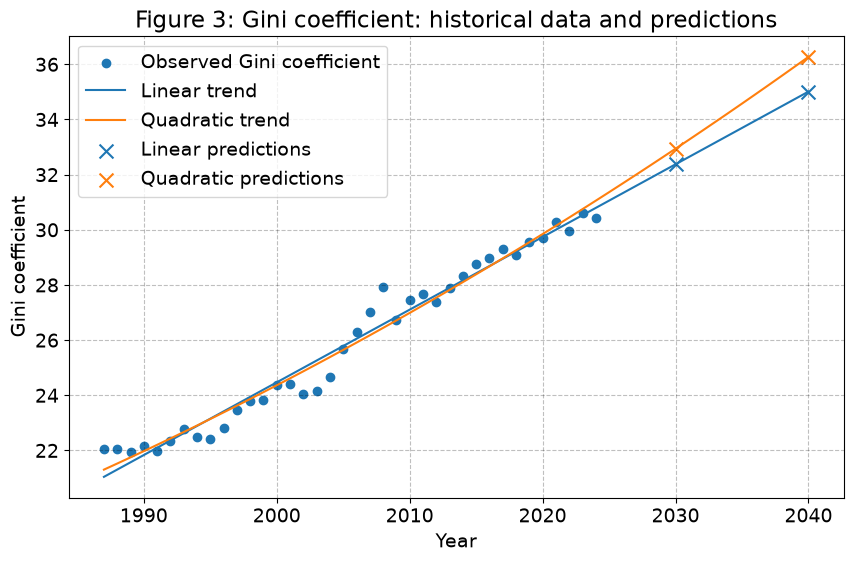

R² linear model:    0.9707
R² quadratic model: 0.9725


In [ ]:
###Calculating the predicted values for the years 2030 and 2040 using both the linear and quadratic models.

years_predict = np.array([2030, 2040])
t_predict = years_predict - 1987

#Linear predictions
pred_linear = (
    beta_linear[0]
    + beta_linear[1] * t_predict
)

#Quadratic predictions
pred_quadratic = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_predict
    + beta_quadratic[2] * t_predict**2
)

print("Linear predictions:", pred_linear)
print("Quadratic predictions:", pred_quadratic)

# Definer x-værdier til dine trendlinjer (f.eks. fra historisk start til 2040)
years_plot = np.arange(1987, 2041) 
t_plot = years_plot - 1987

# Beregn y-værdierne for trendlinjerne
y_linear = (
    beta_linear[0] 
    + beta_linear[1] * t_plot
)

y_quadratic = (
    beta_quadratic[0] 
    + beta_quadratic[1] * t_plot 
    + beta_quadratic[2] * t_plot**2
)

#Plotting the predicted values with the historical values as well.
plt.figure(figsize=(10, 6))


plt.scatter(
    gini['TID'].astype(int),
    y,
    label='Observed Gini coefficient'
)

#Linear trend
linear_line, = plt.plot(
    years_plot,
    y_linear,
    label='Linear trend'
)

#Quadratic trend
quadratic_line, = plt.plot(
    years_plot,
    y_quadratic,
    label='Quadratic trend'
)

#Linear predictions
plt.scatter(
    years_predict,
    pred_linear,
    marker='x',
    s=100,
    color=linear_line.get_color(),
    label='Linear predictions'
)

#Quadratic predictions
plt.scatter(
    years_predict,
    pred_quadratic,
    marker='x',
    s=100,
    color=quadratic_line.get_color(),
    label='Quadratic predictions'
)

plt.xlabel('Year')
plt.ylabel('Gini coefficient')
plt.title('Figure 3: Gini coefficient: historical data and predictions')
plt.legend()

plt.show()

###Calculating how fitting the two specifications fit the historical data. 

#Finding the fitted values for historical observations
y_hat_linear = (
    beta_linear[0]
    + beta_linear[1] * t
)

y_hat_quadratic = (
    beta_quadratic[0]
    + beta_quadratic[1] * t
    + beta_quadratic[2] * t**2
)
#Calculating the R² for both models
def r_squared(y, y_hat):
    
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    
    return 1 - ss_res / ss_tot

r2_linear = r_squared(y, y_hat_linear)
r2_quadratic = r_squared(y, y_hat_quadratic)

print(f"R² linear model:    {r2_linear:.4f}")
print(f"R² quadratic model: {r2_quadratic:.4f}")


Results:

We get the same beta coefficients for both the lienar and the quadratic trend, when using the scipy.optimize.minimize and the np.polyfit tools. 

We see that the quadratic model predicts a larger Gini coefficient compared to that of the linear model. We see that the relative difference between the two models gets bigger the further into the future. 

We see that the predictions for both the linear and the quadratic predictions does not visibly fit the observed values that well. However, the R-squarred value is relatively large, which indicates a great fit. It is larger for the quadratic model, which we would also have expected. 

One should be careful to trust this prediction, since this model only accounts for the actual Gini coefficient. There are many other explanatory variables, that must be taken into consideration. 

**Problem 1.3**

1.3.1:
Computing the correlation across municipalities between the gini coefficient and the top 10 pct. share. 

In [ ]:
## Getting the data for all municipalities for the two tables. 

def load_IFOR41(ULLIG, KOMMUNEDK, TID):
    params = {
        'table': 'IFOR41', 'format': 'BULK', 'lang': 'en',
        'variables': [
            {'code': 'ULLIG', 'values': [ULLIG]},
            {'code': 'KOMMUNEDK', 'values': [KOMMUNEDK]},
            {'code': 'TID', 'values': [TID]}
        ]
    }    
    df = DstApi('IFOR41').get_data(params=params)
    df['INDHOLD'] = df['INDHOLD'].astype(float)
    df = df.rename(columns={'INDHOLD': 'gini', 'TID': 'year'})
    df = df.drop(columns=['ULLIG'])
    
    # Removing '000' (All municipalities)
    df = df[df['KOMMUNEDK'] != '000'] 
    return df

def load_IFOR32(DECILGEN, KOMMUNEDK, TID):
    params = {
        'table': 'IFOR32', 'format': 'BULK', 'lang': 'en',
        'variables': [
            {'code': 'DECILGEN', 'values': [DECILGEN]},
            {'code': 'KOMMUNEDK', 'values': [KOMMUNEDK]},
            {'code': 'TID', 'values': [TID]}
        ]
    }    
    df = DstApi('IFOR32').get_data(params=params)
    df['INDHOLD'] = df['INDHOLD'].astype(float)
    
    # Pivot with both KOMMUNEDK and TID
    df_pivot = df.pivot(index=['KOMMUNEDK', 'TID'], columns='DECILGEN', values='INDHOLD')
    df_pivot['top_10_share'] = df_pivot['Tenth decil'] / df_pivot.sum(axis=1)
    
    # Reset index to get the columns back
    df_final = df_pivot[['top_10_share']].reset_index()
    df_final = df_final.rename(columns={'TID': 'year'})
    
    # Removing '000' (All municipalities)
    df_final = df_final[df_final['KOMMUNEDK'] != '000']
    return df_final

# 1. Getting the data for all municipalities for the two tables
gini_df = load_IFOR41('70', '*', '*')
income_10pct = load_IFOR32('*', '*', '*')

# 2. Merging the tables into a single dataset
df_samlet = pd.merge(gini_df, income_10pct, on=['KOMMUNEDK', 'year'], how='inner', validate='1:1')

# Vis resultatet
print(df_samlet.head())

       KOMMUNEDK  year   gini  top_10_share
0    All Denmark  2016  28.97      0.233832
1     Copenhagen  2016  33.24      0.249130
2  Frederiksberg  2016  34.85      0.267226
3       Ballerup  2016  25.77      0.205321
4        Brøndby  2016  25.71      0.205802


In [ ]:
#Computing the correlation between the two inequality measures for all municipalities in Denmark.
correlation = df_samlet['gini'].corr(df_samlet['top_10_share'])
print(f"Correlation is: {correlation:.4f}")

Correlation is: 0.9605


We see that the correlation between the thwo meassures is a bit lower than the 0.9816 found in 1.2 but the difference is miniscule so the correlation is still very strong at 0.9605. 

1.3.2

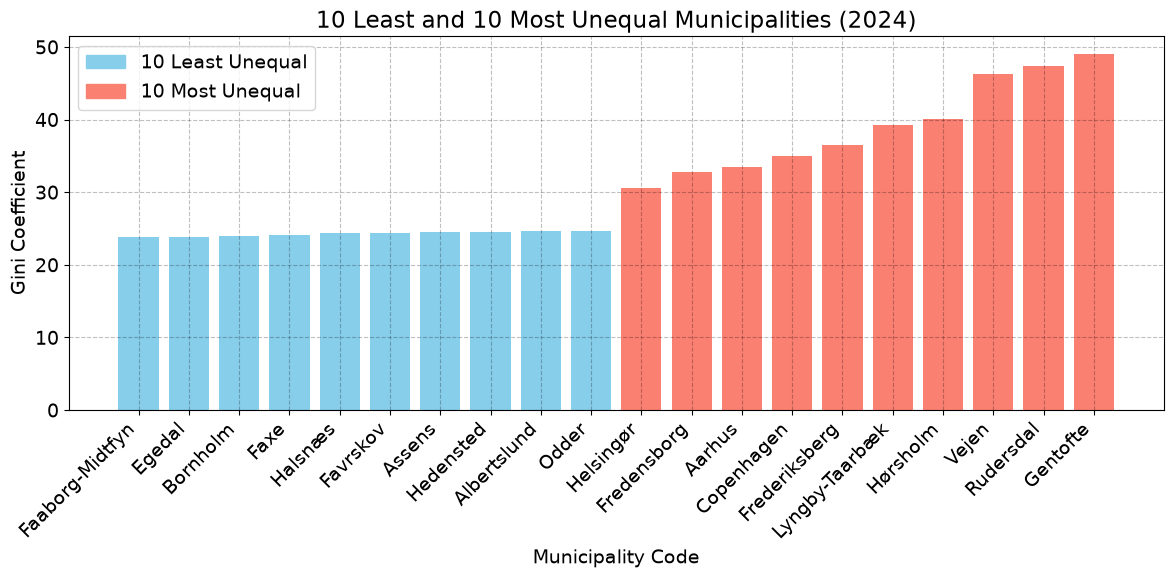

In [ ]:
import matplotlib.patches as mpatches # Import for creating custom legend handles
# 1. Find det seneste år i datasættet
last_year = df_samlet['year'].max()

# 2. Filtrer datasættet til kun at indeholde dette år
df_last_year = df_samlet[df_samlet['year'] == last_year]

# Sorting the dataset by the Gini coefficient
df_sorted = df_last_year.sort_values('gini')

# Extracting the 10 least unequal (lowest Gini) and 10 most unequal (highest Gini)
bottom_10 = df_sorted.head(10)
top_10 = df_sorted.tail(10)

# Combining the two DataFrames for plotting
df_plot = pd.concat([bottom_10, top_10])

# Create the bar chart
plt.figure(figsize=(12, 6))

# We use different colors to easily distinguish the two groups
colors = ['skyblue']*10 + ['salmon']*10
plt.bar(df_plot['KOMMUNEDK'], df_plot['gini'], color=colors)

# Create and add the legend
least_patch = mpatches.Patch(color='skyblue', label='10 Least Unequal')
most_patch = mpatches.Patch(color='salmon', label='10 Most Unequal')
plt.legend(handles=[least_patch, most_patch])

# Formatting the plot
plt.title(f'10 Least and 10 Most Unequal Municipalities ({last_year})')
plt.ylabel('Gini Coefficient')
plt.xlabel('Municipality Code')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the figure
plt.show()

figure 3 show how the inequality level, as meassured by the Gini coefficient, is stable for the least unequal municipalities but has a lot of variation for the 10 most unequal municiaplites in the year 2024.

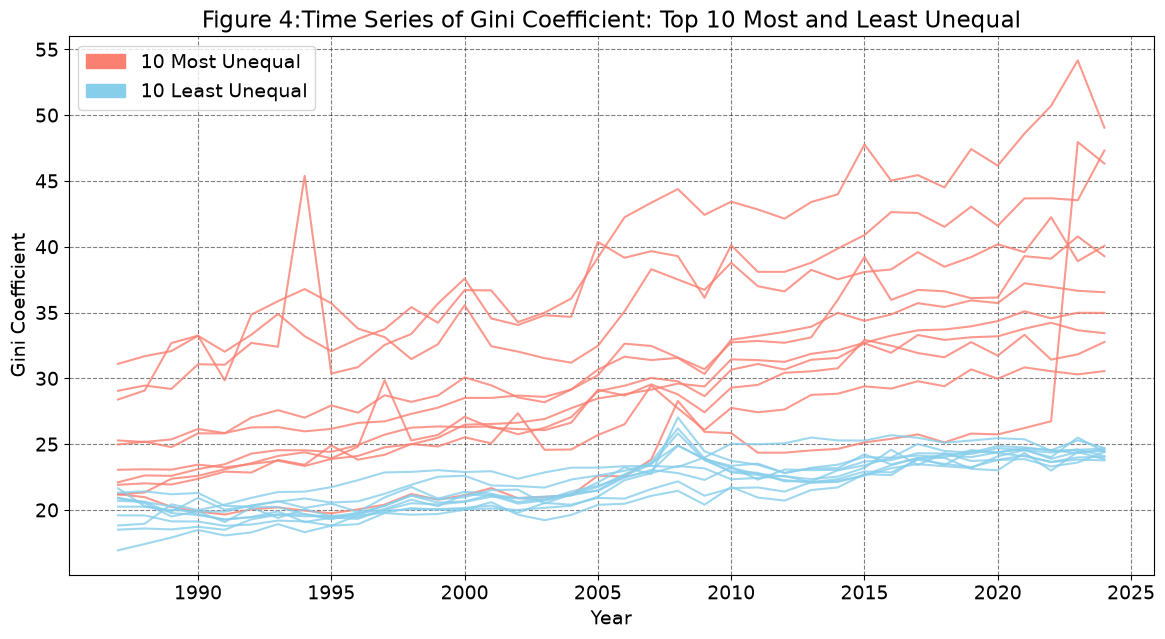

In [ ]:
# Extract municipality names from the top 10 and bottom 10 datasets
top_10_names = top_10['KOMMUNEDK'].tolist()
bottom_10_names = bottom_10['KOMMUNEDK'].tolist()

plt.figure(figsize=(14, 7))

# Plot the 10 most unequal municipalities (red lines)
for kommune in top_10_names:
    df_k = df_samlet[df_samlet['KOMMUNEDK'] == kommune].sort_values('year')
    plt.plot(df_k['year'], df_k['gini'], color='salmon', alpha=0.8, linewidth=1.5)

# Plot the 10 least unequal municipalities (blue lines)
for kommune in bottom_10_names:
    df_k = df_samlet[df_samlet['KOMMUNEDK'] == kommune].sort_values('year')
    plt.plot(df_k['year'], df_k['gini'], color='skyblue', alpha=0.8, linewidth=1.5)

# Formatting the plot
plt.title('Figure 4:Time Series of Gini Coefficient: Top 10 Most and Least Unequal')
plt.xlabel('Year')
plt.ylabel('Gini Coefficient')
plt.grid(True, linestyle='--', alpha=0.5)

# Create custom legend for the two groups
most_patch = mpatches.Patch(color='salmon', label='10 Most Unequal')
least_patch = mpatches.Patch(color='skyblue', label='10 Least Unequal')
plt.legend(handles=[most_patch, least_patch])

# Show the figure
plt.show()


The above plot show that the inequality level for the 10 least unequal municipalities is also relatively stable across time. However, this is not the case for the 10 most unequal municiaplities which dislpay a lot of variation across time which could indicate that the inequality level is driven by few people with very large incomes. 

**1.3.3**

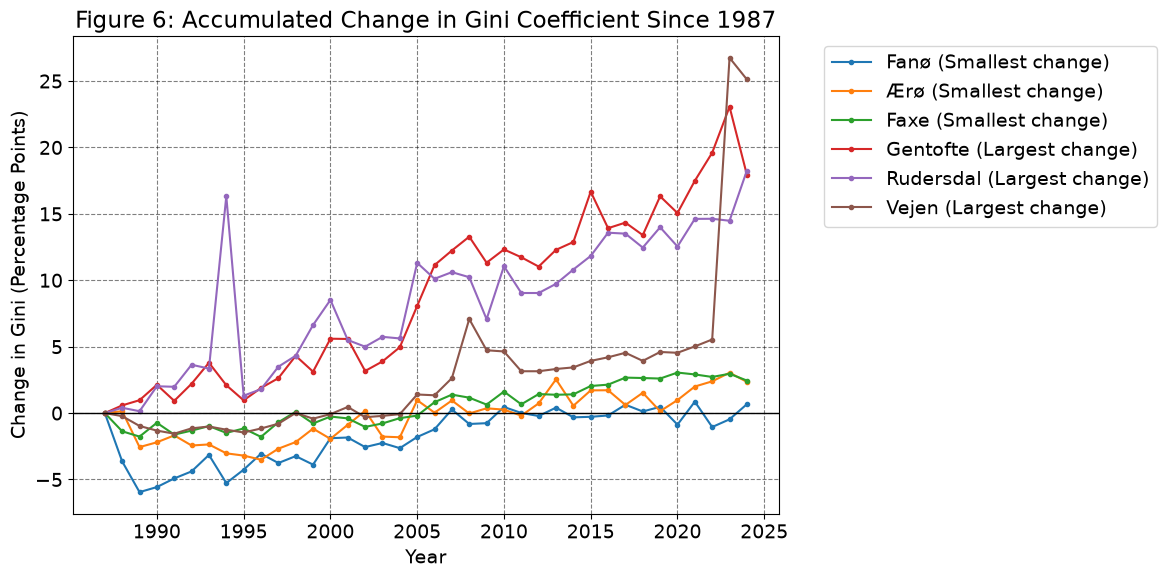

In [72]:
# 1. Find the first and last year in the dataset
first_year = df_samlet['year'].min()
last_year = df_samlet['year'].max()

# 2. Extract data for these two years and set municipality as index
df_first = df_samlet[df_samlet['year'] == first_year].set_index('KOMMUNEDK')
df_last = df_samlet[df_samlet['year'] == last_year].set_index('KOMMUNEDK')

# 3. Calculate the total change in the Gini coefficient
df_change = (df_last['gini'] - df_first['gini']).dropna().sort_values()

# 4. Find the 3 with the smallest and 3 with the largest change
smallest_change_munis = df_change.head(3).index.tolist()
largest_change_munis = df_change.tail(3).index.tolist()
selected_munis = smallest_change_munis + largest_change_munis

# 5. Illustrate the underlying series of the change over time
plt.figure(figsize=(12, 6))
cmap = plt.get_cmap('tab10') 

for i, muni in enumerate(selected_munis):
    # Sort data chronologically
    df_muni = df_samlet[df_samlet['KOMMUNEDK'] == muni].sort_values('year').copy()
    
    # Extract the baseline Gini for the first year
    baseline_gini = df_muni[df_muni['year'] == first_year]['gini'].values[0]
    
    # Calculate the accumulated change over time
    df_muni['gini_change'] = df_muni['gini'] - baseline_gini
    
    # Determine label group
    group = "Smallest change" if muni in smallest_change_munis else "Largest change"
    
    # Plot the line with a unique color
    plt.plot(df_muni['year'], df_muni['gini_change'], 
             color=cmap(i), marker='.', label=f'{muni} ({group})')

# Formatting
plt.title(f'Figure 6: Accumulated Change in Gini Coefficient Since {first_year}')
plt.xlabel('Year')
plt.ylabel('Change in Gini (Percentage Points)')
plt.axhline(0, color='black', linewidth=1) # Reference line at zero change
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

We have chosen to include the top 3 municipalities with the smallest and largest change in the Gini Coefficient. Figure 5 display these changes and we see that the largest changes occur for the municipalities that are also amongst the most unequal (cf. figure 4). The three municipalities with the smallest change 

**PROBLEM 2** 


**2.1) The model is constructed in the attached .py file and imported into the notebook for simulation**



In [ ]:
# ensuring that all updates to the file model is loaded into the notebook when importing:
%load_ext autoreload
%autoreload 2

# Importing the life cycle model from the p2_model.py file:
from p2_model import life_cycle_model

# running the model itself:
model = life_cycle_model()
model.sim_life_cycle_model()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**2.1.1) Printing the simulation and analyzing the sanity checks:**

In [ ]:
import numpy as np

# Printing the raw simulation for the first 5 people and first 6 ages
print("Income shape:", model.income.shape)
print(model.income[:5, :6].round(3))


# 1. Sanity check: education shares
education_shares = np.bincount(
    model.education, minlength=3
) / model.N

expected_education = np.array([0.400, 0.350, 0.250])

print("\nSanity check, Education shares:")
print(
    "Simulated:",
    np.array2string(
        education_shares,
        formatter={'float_kind': lambda x: f"{x:.3f}"}
    )
)
print(
    "Expected: ",
    np.array2string(
        expected_education,
        formatter={'float_kind': lambda x: f"{x:.3f}"}
    )
)
# 2. Sanity check: steady-state unemployment
late = [
    np.mean(model.status[model.status[:, t] >= 0, t] == 0)
    for t in range(model.T - 10, model.T)
]

unemployment_sim = np.mean(late)
unemployment_ss = model.sigma / (model.sigma + model.lam)

print("\nSanity check, Unemployment rate:")
print("Simulated: ", round(unemployment_sim, 3))
print("Expected:  ", round(unemployment_ss, 3))


# 3. Sanity check: mean of psi
psi_mean = np.mean(model.psi)

print("\nSanity check, Mean of psi:")
print(f"Simulated: {psi_mean:.3f}")
print(f"Expected:  {1:.3f}")

Income shape: (50000, 47)
[[0.45  0.35  1.026 1.171 1.164 1.134]
 [0.45  0.45  0.45  0.35  1.2   1.157]
 [0.45  0.45  0.45  0.35  0.824 0.773]
 [0.45  0.35  0.35  0.742 0.743 0.702]
 [0.45  0.35  0.35  0.832 0.802 0.836]]

Sanity check, Education shares:
Simulated: [0.403 0.352 0.246]
Expected:  [0.400 0.350 0.250]

Sanity check, Unemployment rate:
Simulated:  0.077
Expected:   0.077

Sanity check, Mean of psi:
Simulated: 1.000
Expected:  1.000


**2.2.2) Time series plot of the mean and different percentiles**


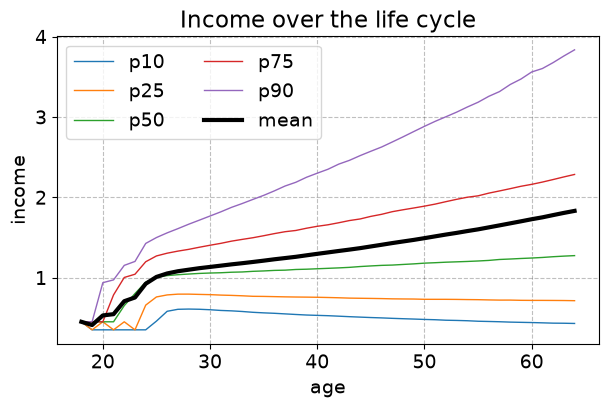

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ages = np.arange(model.age_start, model.age_retire)   # 18..64

# mean and percentiles across the simualtion:
mean_income = model.income.mean(axis=0)
pcts = [10, 25, 50, 75, 90]
P = np.percentile(model.income, pcts, axis=0)        

fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(1, 1, 1)
for i, p in enumerate(pcts):
    ax.plot(ages, P[i], lw=1, label=f'p{p}')
ax.plot(ages, mean_income, lw=3, color='black', label='mean')
ax.set_xlabel('age')
ax.set_ylabel('income')
ax.set_title('Income over the life cycle')
ax.legend(ncol=2)

**2.2.3) Histogram of income distribution for different age groups**

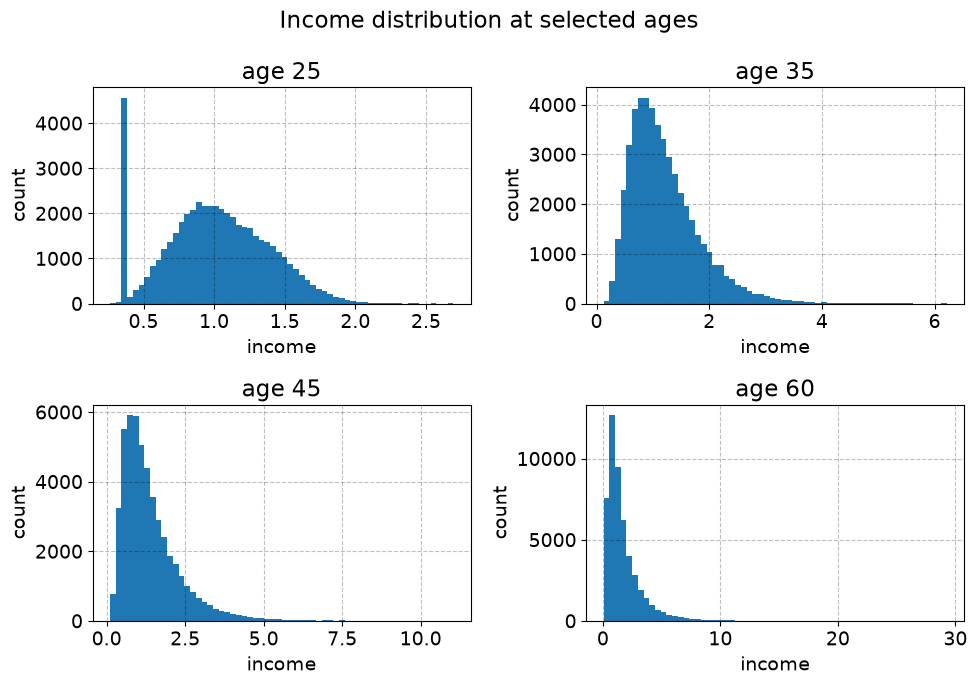

In [ ]:
# histogram over the income distribution at selected ages: 
fig = plt.figure(figsize=(10, 7))
for i, age in enumerate([25, 35, 45, 60]):
    ax = fig.add_subplot(2, 2, i + 1)
    ax.hist(model.income[:, age - model.age_start], bins=60)
    ax.set_title(f'age {age}')
    ax.set_xlabel('income')
    ax.set_ylabel('count')
fig.suptitle('Income distribution at selected ages')
fig.tight_layout()

The income distribution changes considerably over the life cycle. At age 25, the distribution is relatively concentrated, with a noticeable spike at low income. 


At ages 35 and 45, the distribution becomes increasingly right-skewed and more dispersed. Most individuals are concentrated at relatively moderate income levels, while a smaller number have substantially higher incomes, creating a long right tail.


By age 60, the right skewness is even more pronounced. Most individuals remain concentrated at lower income levels, while a small number have accumulated very high incomes. Thus, income dispersion increases substantially with age. This is consistent with the model, as differences in education, employment histories, human-capital growth and accumulated shocks cause individual income paths to diverge over time.

**2.3) The Gini coefficient**